In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

project_name = "wantedash"
os.environ["LANGSMITH_PROJECT"] = project_name

In [2]:
from bot_runner import run_bot_in_background
from discord_alarm_toolkit.discord_toolkit import DiscordAlarmToolkit

In [3]:
run_bot_in_background()

봇 시작 테스크를 이벤트 루프에 등록했습니다.


Tool-Bot Logged in as Wante-#6818. Client is ready.
Tool-Bot Logged in as Wante-#6818. Client is ready.
Tool-Bot Logged in as Wante-#6818. Client is ready.
Tool-Bot Logged in as Wante-#6818. Client is ready.
Tool-Bot Logged in as Wante-#6818. Client is ready.
Tool-Bot Logged in as Wante-#6818. Client is ready.


In [ ]:
# 모델
from langchain_openai import ChatOpenAI
# 프롬프트
from langchain_core.prompts import ChatPromptTemplate
# 타입
from typing import Annotated, TypedDict, Literal, List
# langgraph
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구
from langgraph.prebuilt.tool_node import ToolNode, tools_condition
# 그래프 프롬프트 메시지
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage
# 리듀서
import operator
# 메모리 
from langgraph.checkpoint.memory import MemorySaver

### 노드가 주고받을 상태(State) 정의

In [5]:
class State(TypedDict):
    # 모델 입출력
    messages: Annotated[List[BaseMessage], operator.add]

    # 현재 그래프가 진행중인 단계
    status: Literal["acting", "done"]


### 도구 세팅

In [6]:
discord_toolkit = DiscordAlarmToolkit()
discord_tools = discord_toolkit.get_tools()
discord_tools

[DMAlarmTool(), ChannelAlarmTool()]

### 모델 세팅

In [7]:
llm_agent = ChatOpenAI(
    model='gpt-4o',
    temperature=0
)

agent_chatbot = llm_agent.bind_tools(tools=discord_tools)

### 그래프에 필요한 노드 생성

chatbot 노드

In [8]:
agent_system = """
당신은 사용자의 요청에 따라 Discord 알림을 전송하는 AI 어시스턴트입니다.
당신의 임무는 사용자의 요구사항을 분석하여 '개인 DM 알림' 또는 '채널 전체 공지' 중 적절한 도구를 선택하고,
도구 사용 시 필요한 모든 정보를 수집하여 도구를 호출하는 것입니다.
"""
# 에이전트 노드
def agent_node(state: State) -> State:
    # 에이전트에 전달할 시스템 메시지
    system_message = SystemMessage(content=agent_system)

    # 시스템 메시지와 지금까지의 message를 합친 인풋
    messages_with_system_prompt = [system_message] + state['messages']

    # agent의 답변
    answer = agent_chatbot.invoke(messages_with_system_prompt)
    
    # 상태 업데이트
    return {**state, "messages": [answer], 'status': "acting"}

tool 노드

In [9]:
tool_node = ToolNode(tools=discord_tools)

### 그래프 빌더 생성

In [ ]:
graph_builder = StateGraph(State)

### 그래프에 노드 주입

In [11]:
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

### 고정 엣지 추가

In [12]:
graph_builder.add_edge(START, "agent")
graph_builder.add_edge("tools", END)

### 조건 분기 함수와 조건부 엣지 추가

In [13]:
def route_agent(state: State) -> State:
    """
    agent 노드 이후 실행
    tool_calls가 마지막 메시지에 있으면 'tools'로 없으면 'END'로 라우팅
    """

    if state['messages'][-1].tool_calls:
        return 'tools'
    else:
        return END
    
graph_builder.add_conditional_edges(
    "agent", route_agent, {'tools': 'tools', END: END}
)

### 그래프 컴파일, 구조 출력

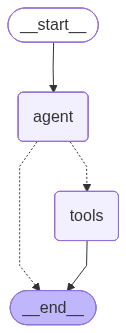

In [14]:
graph = graph_builder.compile()
graph

### 그래프 실행

In [15]:
question = input()

In [16]:
import asyncio

In [16]:
# for 대신 'async for'을 사용
async for event in graph.astream({"messages": [HumanMessage(content=question)]}, stream_mode="values"):
    for key, value in event.items():
        print("-"*30, key, "-"*30)

        if key == "message" and value:
            value[-1].pretty_print()
        else:
            print(value)

------------------------------ messages ------------------------------
[HumanMessage(content="공지-테스트 채널에 알림을 보내야해. 알림 내용은 '배가 아직 너무 부르다' 이야. 제대로 보내줘.", additional_kwargs={}, response_metadata={})]
------------------------------ messages ------------------------------
[HumanMessage(content="공지-테스트 채널에 알림을 보내야해. 알림 내용은 '배가 아직 너무 부르다' 이야. 제대로 보내줘.", additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_jtizKcfs4J0mfXlqyynDTOSn', 'function': {'arguments': '{"channel_name":"공지-테스트","content":"배가 아직 너무 부르다"}', 'name': 'discord_channel_alarm'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 225, 'total_tokens': 254, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fing

In [17]:

# 1. 코드를 async def 함수로 래핑
async def run_graph_stream(question: str):
    """
    LangGraph를 비동기 스트림(.astream)으로 실행합니다.
    """

    # 2. .stream() 대신 .astream() 을 사용하고,
    # for 대신 'async for'을 사용
    async for event in graph.astream({"messages": [HumanMessage(content=question)]}, stream_mode="values"):
        for key, value in event.items():
            print("-"*30, key, "-"*30)

            if key == "message" and value:
                value[-1].pretty_print()
            else:
                print(value)

In [19]:
run_graph_stream(question)

<coroutine object run_graph_stream at 0x000001D750600F40>

In [22]:
result = graph.ainvoke({"messages": [HumanMessage(content=question)]})

result

<coroutine object Pregel.ainvoke at 0x000001D7523825A0>

In [ ]:

for event in graph.stream({"messages": [HumanMessage(content=question)]}, stream_mode="values"):
    for key, value in event.items():
        print("-"*30, key, "-"*30)
        
        if key == "messages" and value:
            value[-1].pretty_print()
        else:
            # 'status', 'report' 등 다른 키들은 그냥 값을 출력
            print(value)